In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC,LinearSVC
from sklearn.metrics import classification_report,f1_score,confusion_matrix,accuracy_score,precision_score,recall_score

In [51]:
data = pd.read_csv("breast-cancer.csv")
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [52]:
data = data.drop("id",axis=1)
data.head(1)

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.8,1001.0,0.1184,0.2776,0.3001,0.1471,0.2419,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189


In [53]:
data.isnull().sum()

diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [54]:
data.duplicated().sum()

np.int64(0)

In [55]:
data.count()

diagnosis                  569
radius_mean                569
texture_mean               569
perimeter_mean             569
area_mean                  569
smoothness_mean            569
compactness_mean           569
concavity_mean             569
concave points_mean        569
symmetry_mean              569
fractal_dimension_mean     569
radius_se                  569
texture_se                 569
perimeter_se               569
area_se                    569
smoothness_se              569
compactness_se             569
concavity_se               569
concave points_se          569
symmetry_se                569
fractal_dimension_se       569
radius_worst               569
texture_worst              569
perimeter_worst            569
area_worst                 569
smoothness_worst           569
compactness_worst          569
concavity_worst            569
concave points_worst       569
symmetry_worst             569
fractal_dimension_worst    569
dtype: int64

In [56]:
data['diagnosis'].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

In [57]:
le = LabelEncoder()
data['diagnosis'] = le.fit_transform(data['diagnosis'])

In [58]:
data.tail(3)

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
566,1,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,1,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400
568,0,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,...,9.456,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039


In [59]:
data['diagnosis'].value_counts()

diagnosis
0    357
1    212
Name: count, dtype: int64

In [60]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

In [61]:
data.describe()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,0.372583,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,0.483918,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,0.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,0.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,0.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,1.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,1.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [62]:
target = data['diagnosis']

In [63]:
data.drop('diagnosis',axis=1,inplace=True)

In [64]:
corr = data.corr().abs()
high_corr = corr[corr > 0.9]
print(high_corr)

                         radius_mean  texture_mean  perimeter_mean  area_mean  \
radius_mean                 1.000000           NaN        0.997855   0.987357   
texture_mean                     NaN      1.000000             NaN        NaN   
perimeter_mean              0.997855           NaN        1.000000   0.986507   
area_mean                   0.987357           NaN        0.986507   1.000000   
smoothness_mean                  NaN           NaN             NaN        NaN   
compactness_mean                 NaN           NaN             NaN        NaN   
concavity_mean                   NaN           NaN             NaN        NaN   
concave points_mean              NaN           NaN             NaN        NaN   
symmetry_mean                    NaN           NaN             NaN        NaN   
fractal_dimension_mean           NaN           NaN             NaN        NaN   
radius_se                        NaN           NaN             NaN        NaN   
texture_se                  

In [65]:
drop_col = ['perimeter_mean','area_mean','radius_worst','perimeter_worst','area_worst']
data.drop(columns=drop_col,axis=1,inplace=True)

In [66]:
data.head()

,radius_mean,texture_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,...,concave points_se,symmetry_se,fractal_dimension_se,texture_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,...,0.01587,0.03003,0.006193,17.33,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,...,0.01340,0.01389,0.003532,23.41,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,...,0.02058,0.02250,0.004571,25.53,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,...,0.01867,0.05963,0.009208,26.50,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,...,0.01885,0.01756,0.005115,16.67,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [67]:
data = pd.concat([data,target],axis=1)

In [68]:
data.head()

,radius_mean,texture_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,...,symmetry_se,fractal_dimension_se,texture_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diagnosis
0,17.99,10.38,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,...,0.03003,0.006193,17.33,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,...,0.01389,0.003532,23.41,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,...,0.02250,0.004571,25.53,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,...,0.05963,0.009208,26.50,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,...,0.01756,0.005115,16.67,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


In [69]:
low_corr = data.corr()['diagnosis'].abs() < 0.1
print(low_corr)


radius_mean                False
texture_mean               False
smoothness_mean            False
compactness_mean           False
concavity_mean             False
concave points_mean        False
symmetry_mean              False
fractal_dimension_mean      True
radius_se                  False
texture_se                  True
perimeter_se               False
area_se                    False
smoothness_se               True
compactness_se             False
concavity_se               False
concave points_se          False
symmetry_se                 True
fractal_dimension_se        True
texture_worst              False
smoothness_worst           False
compactness_worst          False
concavity_worst            False
concave points_worst       False
symmetry_worst             False
fractal_dimension_worst    False
diagnosis                  False
Name: diagnosis, dtype: bool


In [70]:
drop_cols = ['fractal_dimension_mean','texture_se','smoothness_se','symmetry_se','fractal_dimension_se']
data.drop(columns=drop_cols,axis=1,inplace=True)

In [71]:
data.head()


,radius_mean,texture_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,radius_se,perimeter_se,area_se,...,concavity_se,concave points_se,texture_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diagnosis
0,17.99,10.38,0.11840,0.27760,0.3001,0.14710,0.2419,1.0950,8.589,153.40,...,0.05373,0.01587,17.33,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,0.08474,0.07864,0.0869,0.07017,0.1812,0.5435,3.398,74.08,...,0.01860,0.01340,23.41,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,0.10960,0.15990,0.1974,0.12790,0.2069,0.7456,4.585,94.03,...,0.03832,0.02058,25.53,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,0.14250,0.28390,0.2414,0.10520,0.2597,0.4956,3.445,27.23,...,0.05661,0.01867,26.50,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,0.10030,0.13280,0.1980,0.10430,0.1809,0.7572,5.438,94.44,...,0.05688,0.01885,16.67,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


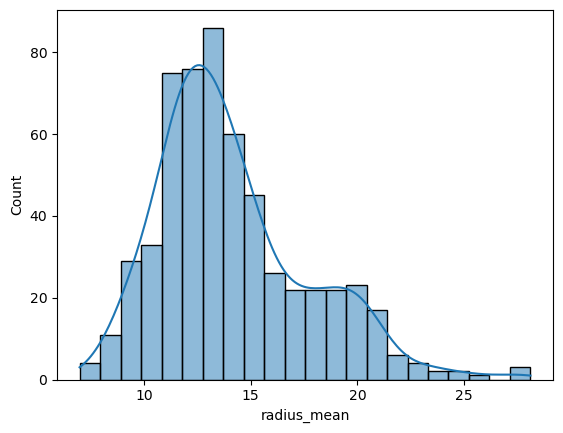

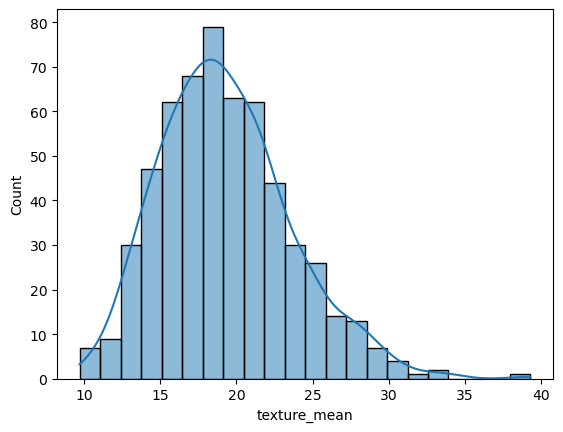

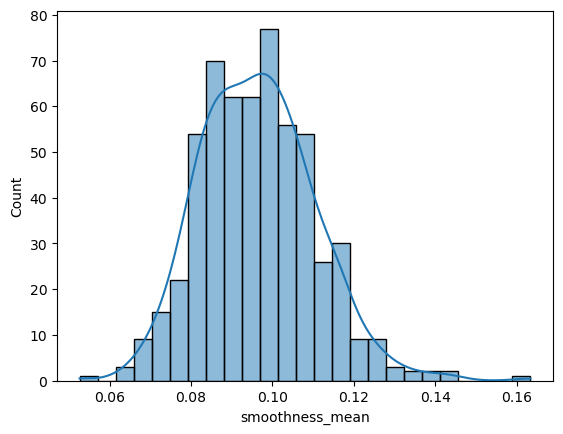

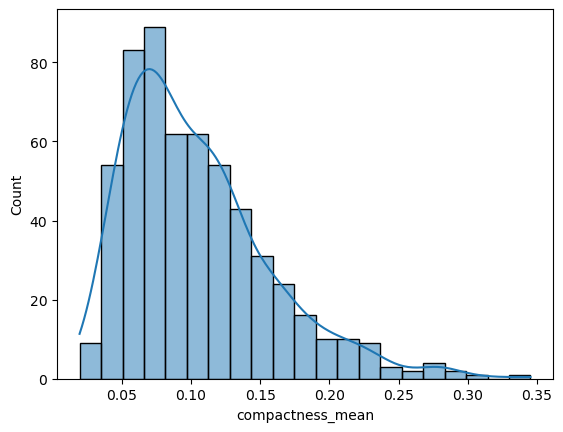

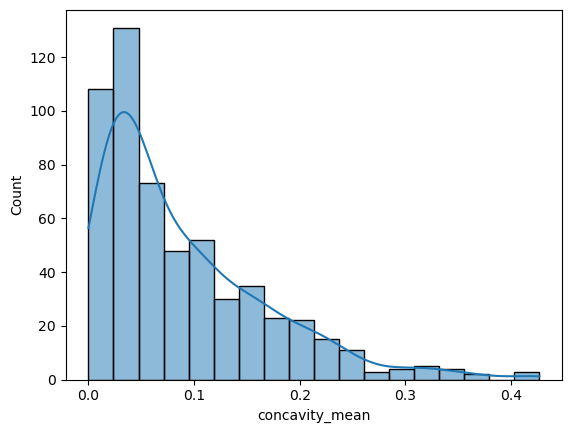

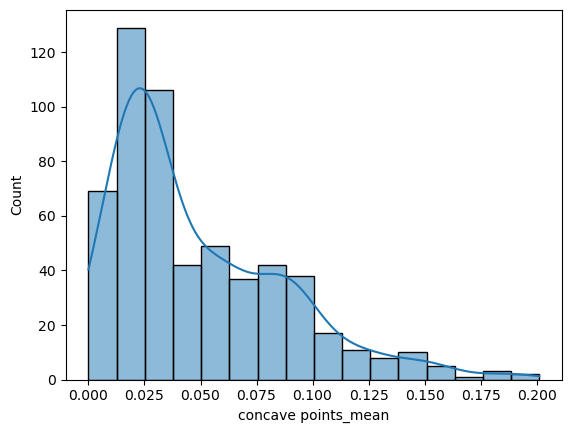

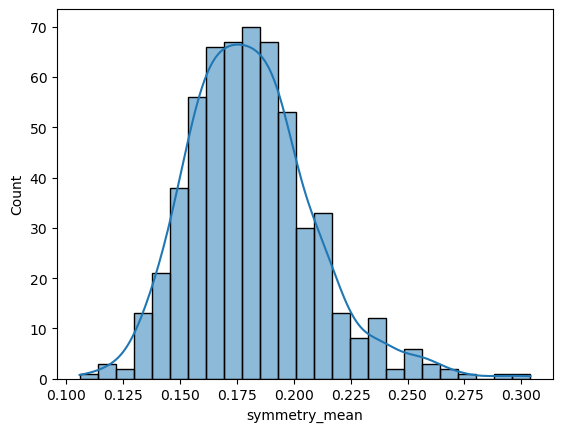

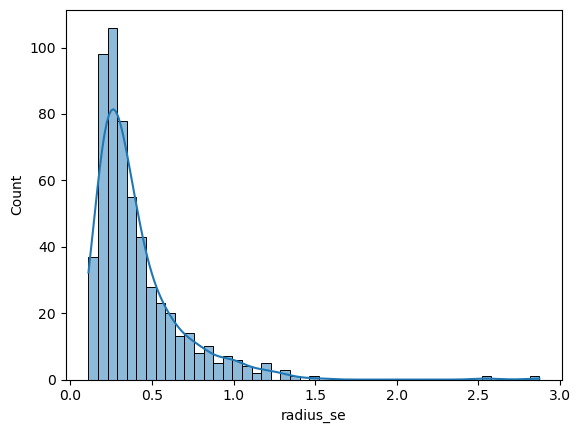

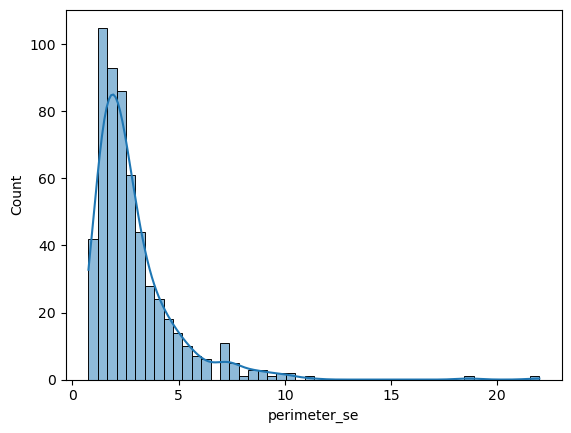

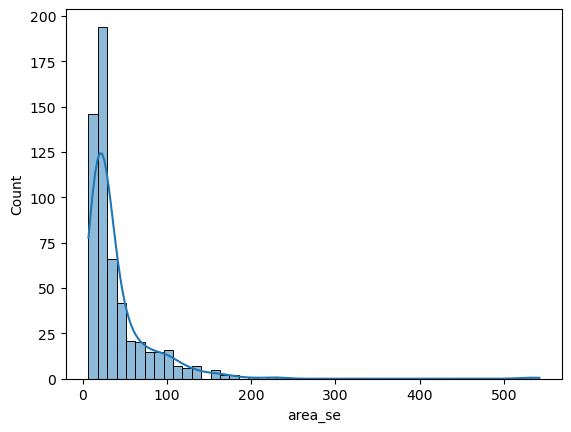

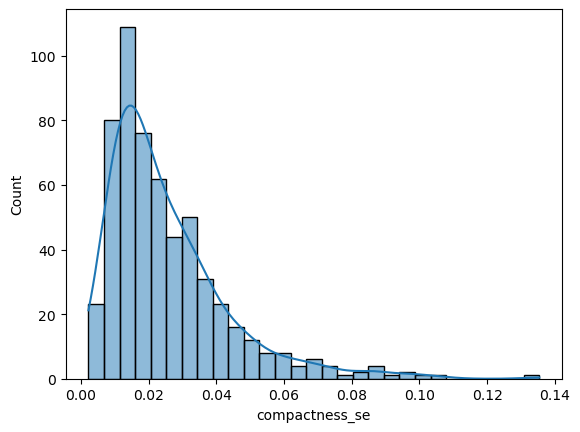

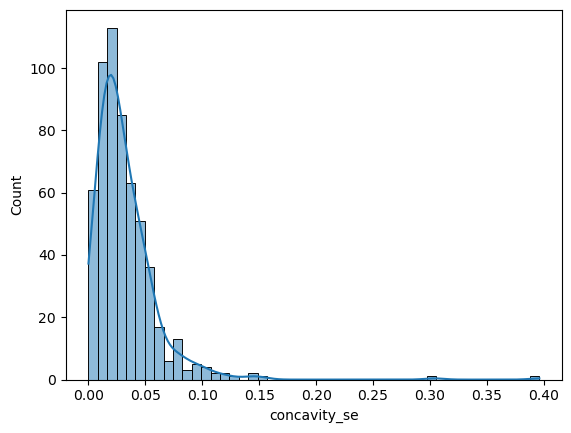

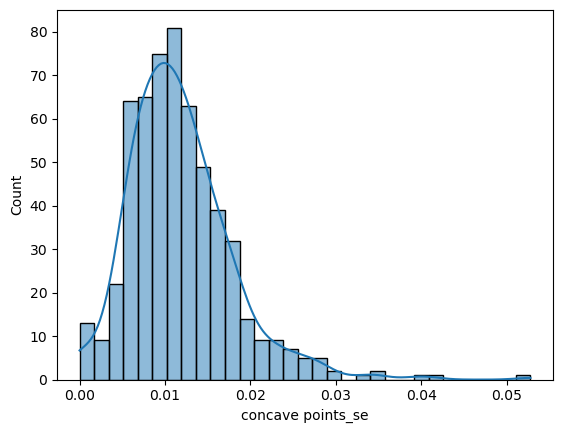

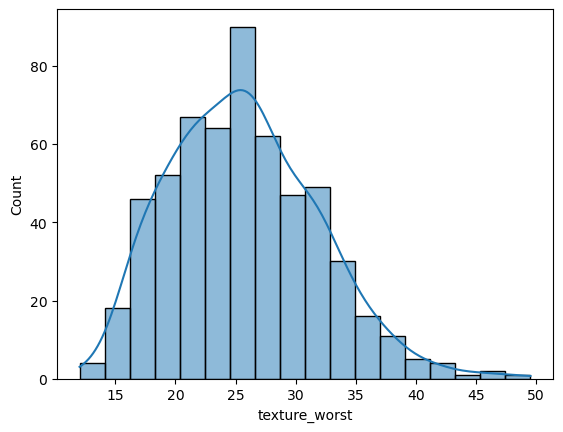

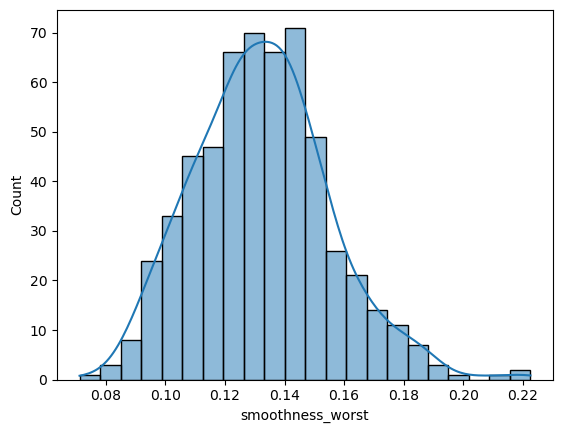

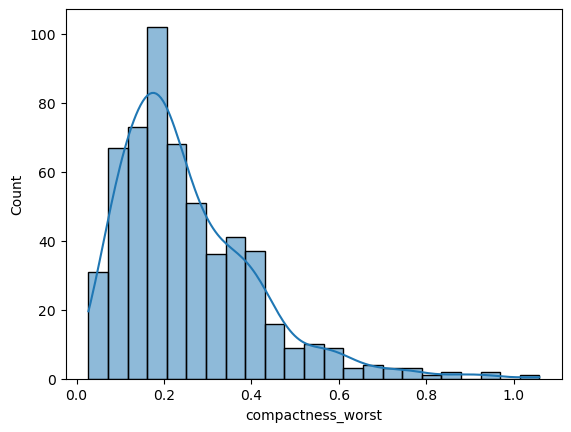

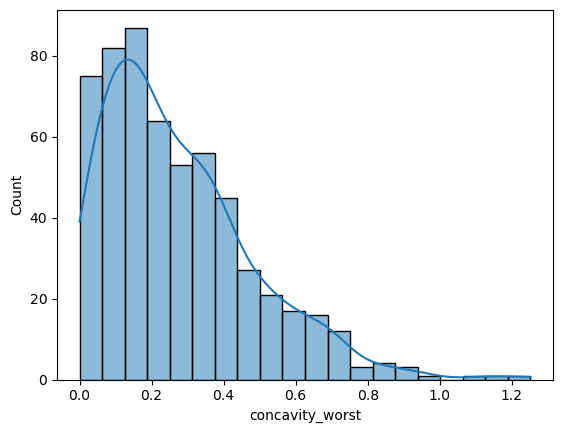

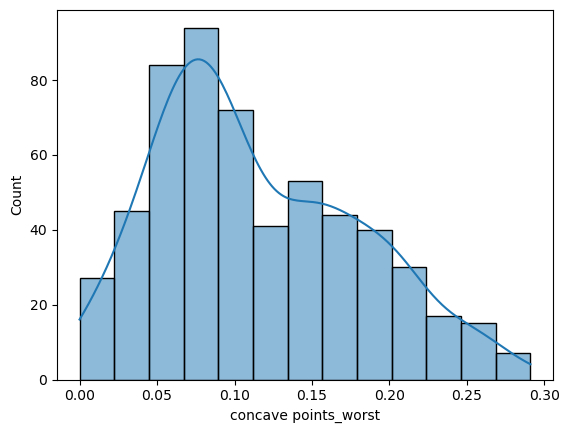

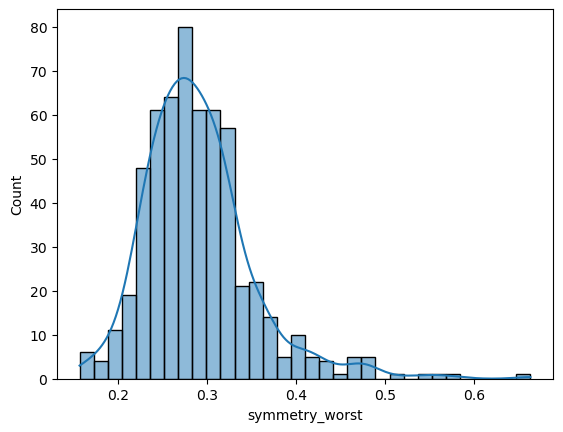

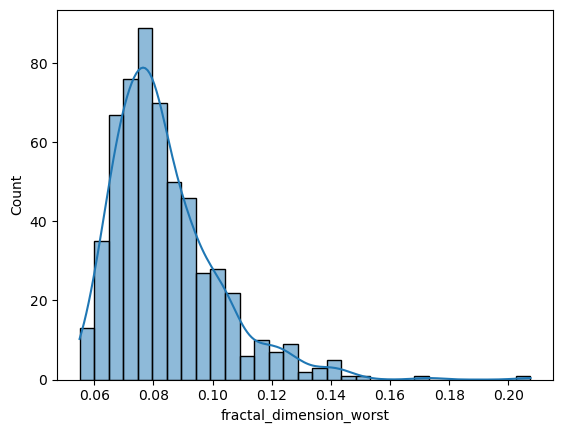

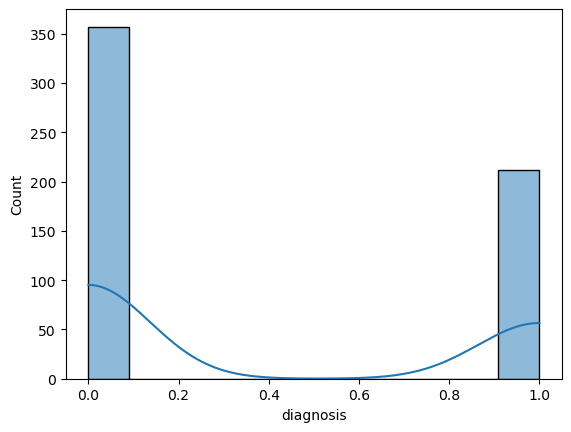

In [72]:
for col in data.columns:
    plt.Figure(figsize=(1,0.5))
    sns.histplot(data[col],kde=True)
    plt.show()

In [73]:
x = data.drop('diagnosis',axis=1)
y = data['diagnosis']

In [74]:
x.shape
y.shape

(569,)

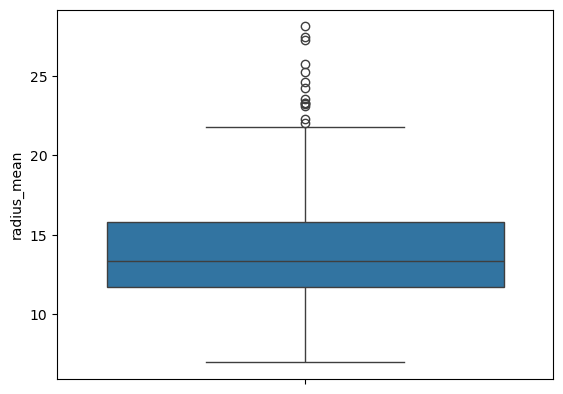

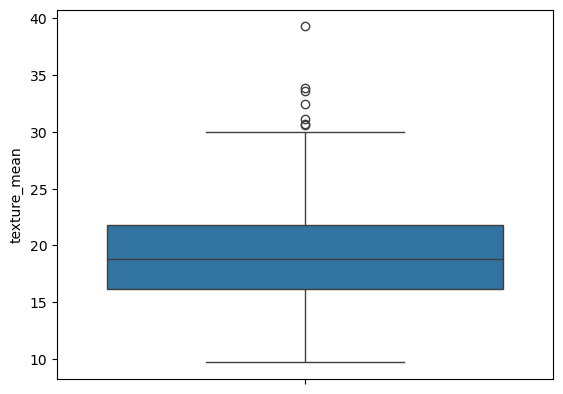

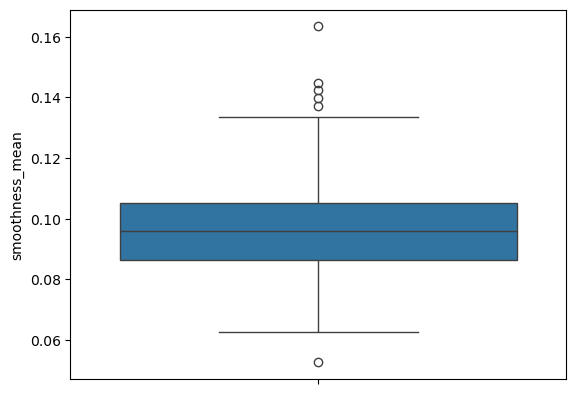

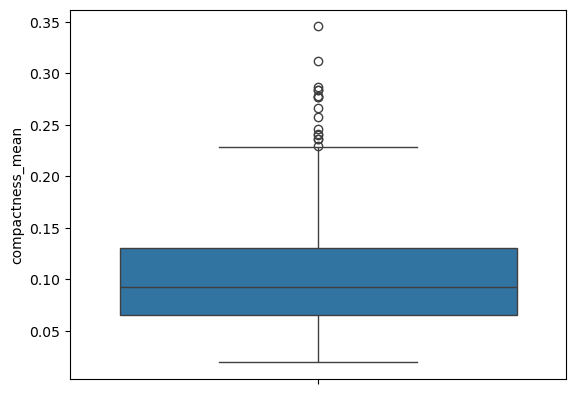

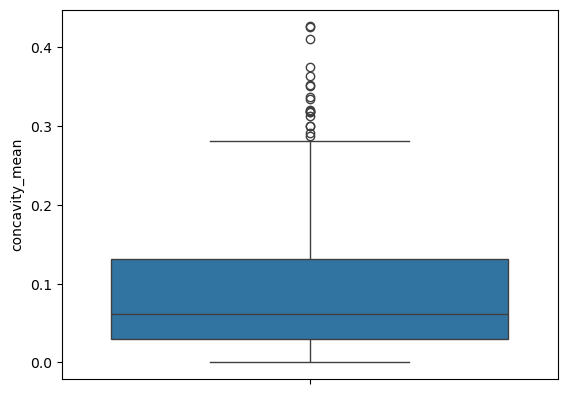

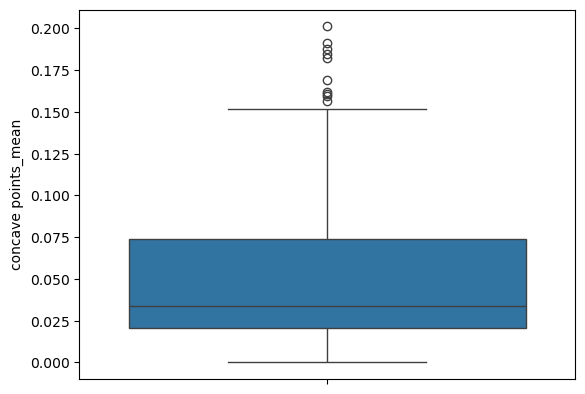

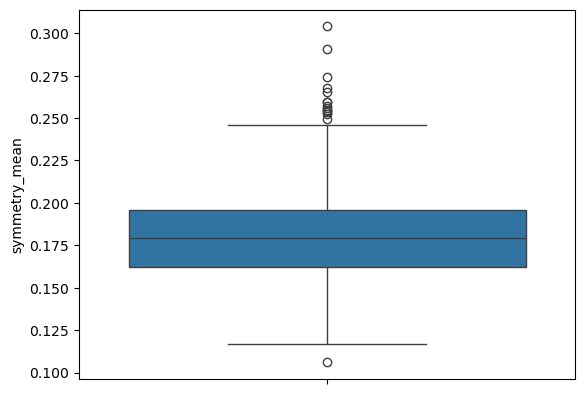

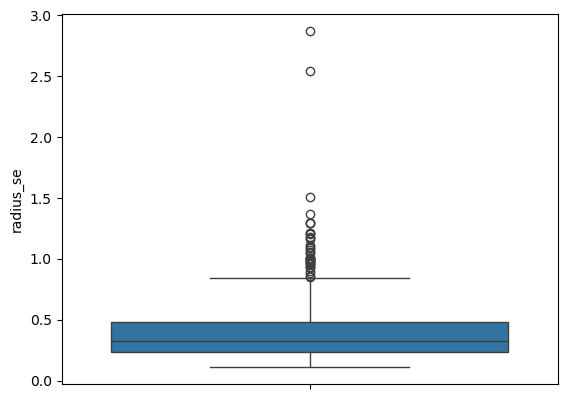

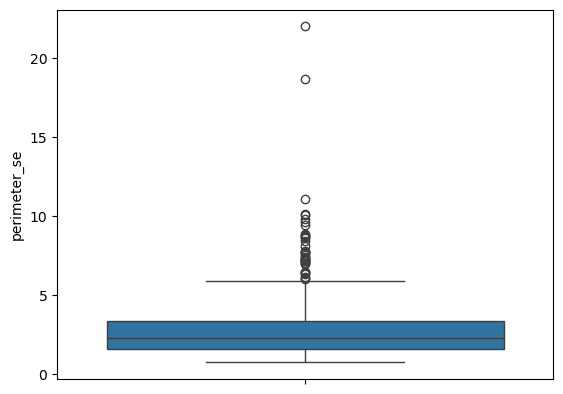

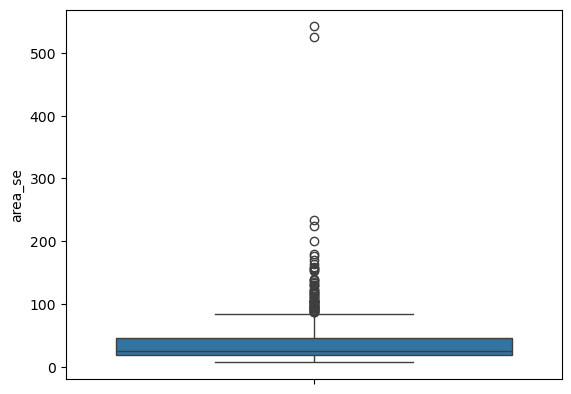

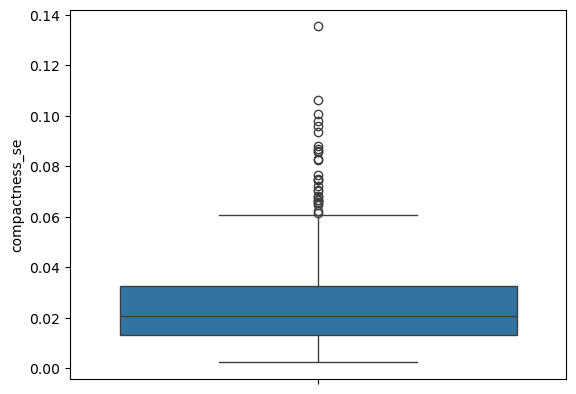

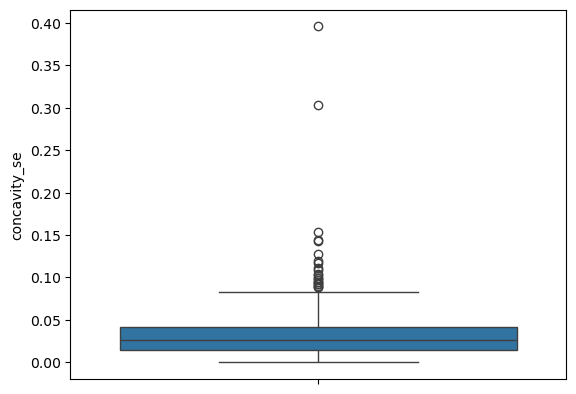

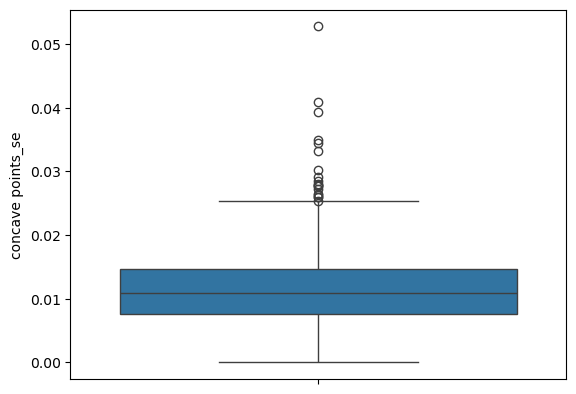

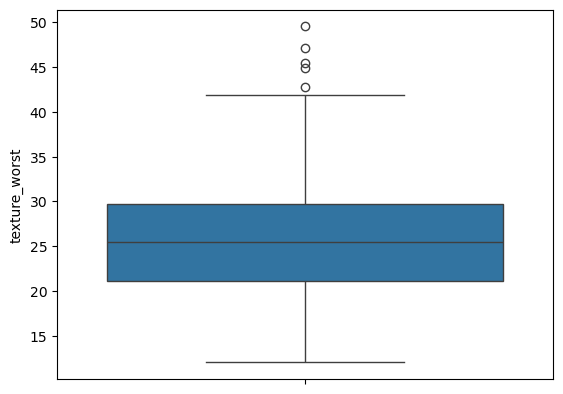

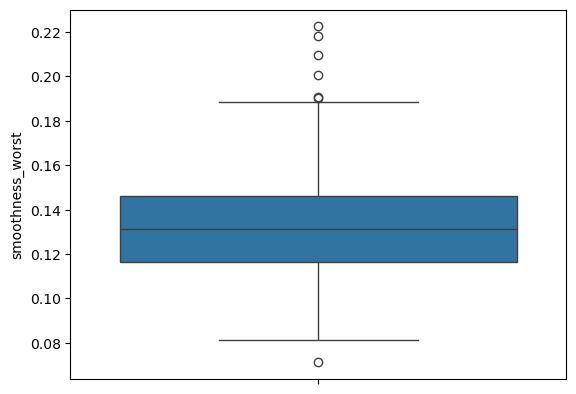

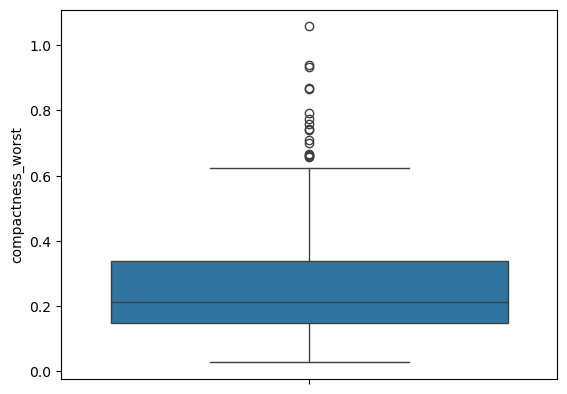

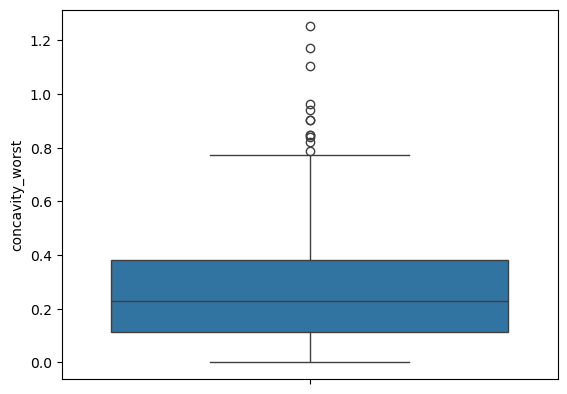

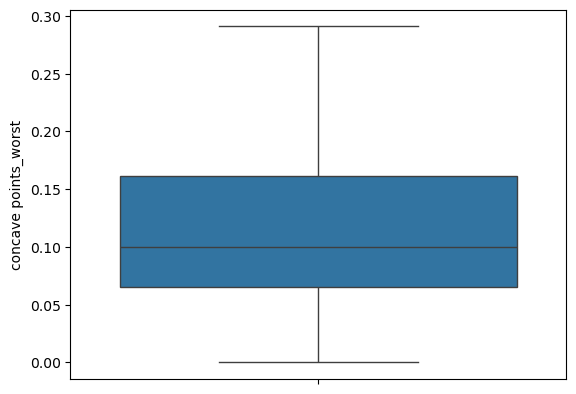

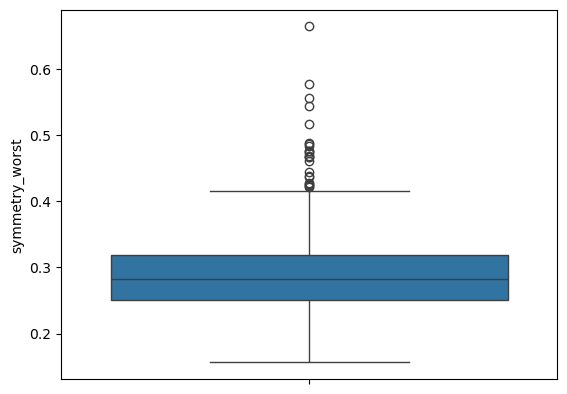

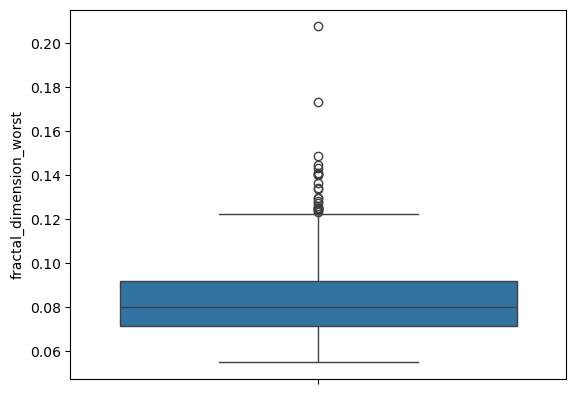

In [75]:
for c in x.columns:
    plt.Figure(figsize=(2,1))
    sns.boxplot(x[c])
    plt.show()

In [76]:
x.skew()

radius_mean                0.942380
texture_mean               0.650450
smoothness_mean            0.456324
compactness_mean           1.190123
concavity_mean             1.401180
concave points_mean        1.171180
symmetry_mean              0.725609
radius_se                  3.088612
perimeter_se               3.443615
area_se                    5.447186
compactness_se             1.902221
concavity_se               5.110463
concave points_se          1.444678
texture_worst              0.498321
smoothness_worst           0.415426
compactness_worst          1.473555
concavity_worst            1.150237
concave points_worst       0.492616
symmetry_worst             1.433928
fractal_dimension_worst    1.662579
dtype: float64

In [77]:
for i in x.columns:
    skw = x[i].skew()

    if abs(skw) > 0.5:
        q1 = x[i].quantile(0.25)
        q3 = x[i].quantile(0.75)
        iqr = q3 - q1
        low_lim = q1 - 1.5 * iqr
        upp_lim = q3 + 1.5 * iqr
    else:
        mean = x[i].mean()
        std = x[i].std()
        low_lim = mean - 3 * std
        upp_lim = mean + 3 * std
    
    x[i] = x[i].clip(low_lim,upp_lim)



In [78]:
selected_features = x.columns.tolist()
print(selected_features)

['radius_mean', 'texture_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'radius_se', 'perimeter_se', 'area_se', 'compactness_se', 'concavity_se', 'concave points_se', 'texture_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']


In [79]:
scaler = StandardScaler()
x = scaler.fit_transform(x)

In [80]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [81]:
#svc = LinearSVC(C=1,max_iter=1000,random_state=42)

In [82]:
#svc.fit(x_train,y_train)

In [83]:
svc = SVC(C=1,coef0=1,kernel='poly',degree=3,gamma='scale',max_iter=1000)

In [84]:
lin_model = LinearSVC(max_iter=10000)
rbf_model = SVC(kernel='rbf')

lin_model.fit(x_train, y_train)
rbf_model.fit(x_train, y_train)

print("Linear:", accuracy_score(y_test, lin_model.predict(x_test)))
print("RBF:", accuracy_score(y_test, rbf_model.predict(x_test)))

Linear: 0.9649122807017544
RBF: 0.9649122807017544


In [85]:
svc.fit(x_train,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'poly'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [86]:
y_pred = svc.predict(x_test)

In [87]:
svc.decision_function(x_test)

array([-8.03459076e-01,  3.54579031e+00,  1.71775395e+00, -2.78249101e+00,
       -3.71019540e+00,  1.04669418e+01,  5.79283845e+00,  5.33604092e-01,
        3.71871781e-01, -2.30847923e+00, -9.63950460e-01,  1.19365423e+00,
       -1.80349749e+00,  1.06471729e+00, -2.38818985e+00,  3.63268593e+00,
       -2.61633808e+00, -3.71167869e+00, -3.76740238e+00,  4.71715560e+00,
       -9.22642391e-01, -1.77522295e+00,  8.35189528e+00, -2.78879974e+00,
       -2.81849015e+00, -3.02476761e+00, -2.61466811e+00, -2.30697897e+00,
       -2.23144884e+00,  3.29740448e+00, -2.78022661e+00, -3.00438674e+00,
       -1.57485235e+00, -1.71184192e+00, -2.72705604e+00, -1.71515951e+00,
        1.06658747e+00, -2.18861287e+00,  2.92004018e+00, -1.08882948e+00,
       -3.02137599e+00,  2.73119077e+00, -2.48469531e+00, -2.30445957e+00,
       -4.83772889e-01, -6.67815909e-01, -3.88560459e+00, -1.82042069e+00,
       -1.11527002e+00, -2.83855097e+00,  3.01117518e+00,  5.41980165e+00,
        8.78286042e-03, -

In [88]:
cr = print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97        71
           1       0.95      0.95      0.95        43

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114



0 - B
1 - M

In [89]:
cm = confusion_matrix(y_test,y_pred)

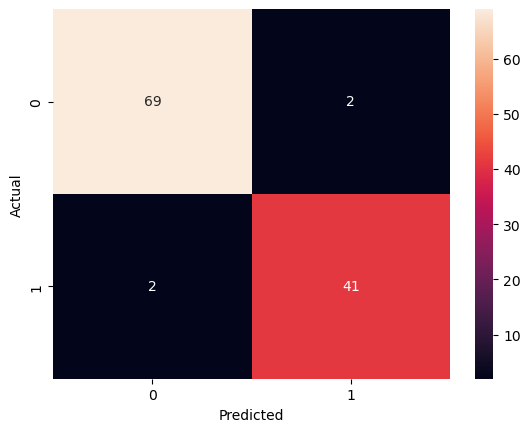

In [90]:
sns.heatmap(cm,annot=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [96]:
import joblib 

In [ ]:
joblib.dump(svc,'D:\\AI Learning\\SVC\saved_model\\breast_cancer_model.pkl')

In [ ]:
joblib.dump(scaler,'D:\\AI Learning\\SVC\saved_model\\scaler.pkl')

In [95]:
joblib.dump(selected_features,'D:\\AI Learning\\SVC\saved_model\\features.pkl')

['D:\\AI Learning\\SVC\\saved_model\\features.pkl']

In [102]:
model = joblib.load('D:\\AI Learning\\SVC\\saved_model\\breast_cancer_model.pkl')
scaler = joblib.load('D:\\AI Learning\\SVC\\saved_model\\scaler.pkl')
features = joblib.load('D:\\AI Learning\\SVC\\saved_model\\features.pkl')

In [106]:
sample = x_test[0].reshape(1, -1)

sample_scaled = scaler.transform(sample)

prediction = model.predict(sample_scaled)

print('Prediction:')

if prediction[0] == 0:
    print('Malignant')
else:
    print('Benign')

print('Actual:')

if y_test.iloc[0] == 0:   # y_test is still pandas
    print('Malignant')
else:
    print('Benign')

Prediction:
Malignant
Actual:
Malignant


c:\Users\PC\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
